In [1]:
import pandas as pd
import torch
import matplotlib.pyplot as plt
import numpy as np
from torch.utils.data import Dataset, DataLoader
from transformers import BertTokenizer, BertForSequenceClassification, AdamW
from sklearn.model_selection import train_test_split
from tqdm import tqdm
from sklearn.metrics import cohen_kappa_score
from scipy.stats import wasserstein_distance  # For EMD

In [2]:
# Load Processed Data
df = pd.read_csv("processed_data.csv")  
tokenizer = BertTokenizer.from_pretrained("bert-base-uncased")

In [3]:
# Create Dataset Class
class EssayDataset(Dataset):
    def __init__(self, df, tokenizer, max_length=512):
        self.essays = df["clean_essay"].tolist()
        self.scores = df["final_score"].tolist()
        self.tokenizer = tokenizer
        self.max_length = max_length

    def __len__(self):
        return len(self.essays)

    def __getitem__(self, idx):
        inputs = self.tokenizer(
            self.essays[idx],
            padding="max_length",
            truncation=True,
            max_length=self.max_length,
            return_tensors="pt",
        )
        label = torch.tensor(self.scores[idx], dtype=torch.float)
        return {
            "input_ids": inputs["input_ids"].squeeze(0),
            "attention_mask": inputs["attention_mask"].squeeze(0),
            "label": label,
        }


In [4]:
# Split Data into Train & Validation Sets
train_df, val_df = train_test_split(df, test_size=0.2, random_state=42)
train_dataset = EssayDataset(train_df, tokenizer)
val_dataset = EssayDataset(val_df, tokenizer)
train_loader = DataLoader(train_dataset, batch_size=8, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=8, shuffle=False)


In [5]:
# Define BERT Model
model = BertForSequenceClassification.from_pretrained("bert-base-uncased", num_labels=1)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


BertForSequenceClassification(
  (bert): BertModel(
    (embeddings): BertEmbeddings(
      (word_embeddings): Embedding(30522, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (token_type_embeddings): Embedding(2, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (encoder): BertEncoder(
      (layer): ModuleList(
        (0-11): 12 x BertLayer(
          (attention): BertAttention(
            (self): BertSdpaSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): BertSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
              (LayerNorm): LayerNorm((768,), eps=1e

In [6]:
# Training Components
optimizer = AdamW(model.parameters(), lr=2e-5)
loss_fn = torch.nn.MSELoss()

c:\Users\Aditi\anaconda3\Lib\site-packages\transformers\optimization.py:591: FutureWarning: This implementation of AdamW is deprecated and will be removed in a future version. Use the PyTorch implementation torch.optim.AdamW instead, or set `no_deprecation_warning=True` to disable this warning
  warnings.warn(


In [7]:
# Early Stopping Parameters
patience = 3
best_val_loss = float("inf")
epochs_no_improve = 0


In [8]:
# Train the Model with Early Stopping
epochs = 5
train_losses, val_losses = [], []

for epoch in range(epochs):
    model.train()
    epoch_loss = 0

    for batch in tqdm(train_loader):
        input_ids = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)
        labels = batch["label"].to(device).unsqueeze(1)

        optimizer.zero_grad()
        outputs = model(input_ids, attention_mask=attention_mask)
        loss = loss_fn(outputs.logits, labels)
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item()

    train_loss = epoch_loss / len(train_loader)
    train_losses.append(train_loss)

    # Validation
    model.eval()
    val_loss = 0
    predictions = []
    true_labels = []
    
    with torch.no_grad():
        for batch in val_loader:
            input_ids = batch["input_ids"].to(device)
            attention_mask = batch["attention_mask"].to(device)
            labels = batch["label"].to(device).unsqueeze(1)

            outputs = model(input_ids, attention_mask=attention_mask)
            loss = loss_fn(outputs.logits, labels)
            val_loss += loss.item()

            predictions.extend(outputs.logits.cpu().numpy().flatten())
            true_labels.extend(labels.cpu().numpy().flatten())

    val_loss /= len(val_loader)
    val_losses.append(val_loss)

    # Compute Evaluation Metrics
    qwk = cohen_kappa_score(np.round(predictions), np.round(true_labels), weights="quadratic")
    emd = wasserstein_distance(true_labels, predictions)

    print(f"Epoch {epoch+1}: Train Loss = {train_loss:.4f}, Validation Loss = {val_loss:.4f}, QWK = {qwk:.4f}, EMD = {emd:.4f}")

    # Early Stopping Check
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        epochs_no_improve = 0
        torch.save(model.state_dict(), "best_bert_model.pth")  
    else:
        epochs_no_improve += 1

    if epochs_no_improve >= patience:
        print("Early stopping triggered. Training stopped.")
        break


100%|██████████| 1298/1298 [9:56:48<00:00, 27.59s/it]  


Epoch 1: Train Loss = 3.0279, Validation Loss = 2.0023, QWK = 0.7980, EMD = 0.5411


100%|██████████| 1298/1298 [10:20:17<00:00, 28.67s/it] 


Epoch 2: Train Loss = 1.7294, Validation Loss = 2.1232, QWK = 0.8035, EMD = 0.5707


100%|██████████| 1298/1298 [9:21:30<00:00, 25.96s/it]  


Epoch 3: Train Loss = 1.2601, Validation Loss = 2.1051, QWK = 0.7966, EMD = 0.5223


100%|██████████| 1298/1298 [9:57:20<00:00, 27.61s/it]  


Epoch 4: Train Loss = 0.8472, Validation Loss = 2.0486, QWK = 0.8143, EMD = 0.3342
Early stopping triggered. Training stopped.


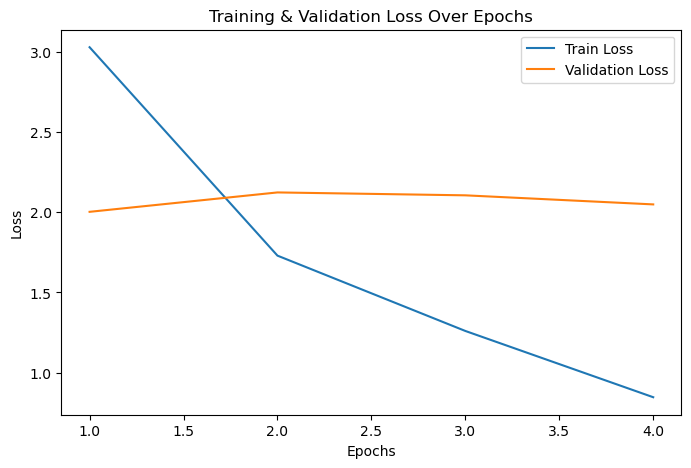

In [9]:
# Plot Loss Graph
plt.figure(figsize=(8, 5))
plt.plot(range(1, len(train_losses) + 1), train_losses, label="Train Loss")
plt.plot(range(1, len(val_losses) + 1), val_losses, label="Validation Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.title("Training & Validation Loss Over Epochs")
plt.show()

In [10]:
# Load Best Model for Predictions
model.load_state_dict(torch.load("best_bert_model.pth"))
model.eval()


BertForSequenceClassification(
  (bert): BertModel(
    (embeddings): BertEmbeddings(
      (word_embeddings): Embedding(30522, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (token_type_embeddings): Embedding(2, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (encoder): BertEncoder(
      (layer): ModuleList(
        (0-11): 12 x BertLayer(
          (attention): BertAttention(
            (self): BertSdpaSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): BertSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
              (LayerNorm): LayerNorm((768,), eps=1e

In [11]:
# Generate Final Predictions
final_predictions = []
true_labels = []

with torch.no_grad():
    for batch in val_loader:
        input_ids = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)
        labels = batch["label"].to(device).unsqueeze(1)

        outputs = model(input_ids, attention_mask=attention_mask)
        final_predictions.extend(outputs.logits.cpu().numpy().flatten())
        true_labels.extend(labels.cpu().numpy().flatten())


In [12]:
# Compute Final Metrics
final_qwk = cohen_kappa_score(np.round(final_predictions), np.round(true_labels), weights="quadratic")
final_emd = wasserstein_distance(true_labels, final_predictions)


In [13]:
# Save Predictions & Metrics
val_df["predicted_score"] = final_predictions
val_df.to_csv("bert_predictions.csv", index=False)


In [14]:
print(f"Final QWK Score: {final_qwk:.4f}")
print(f"Final EMD Score: {final_emd:.4f}")
print("Predictions saved!")


Final QWK Score: 0.7980
Final EMD Score: 0.5411
Predictions saved!


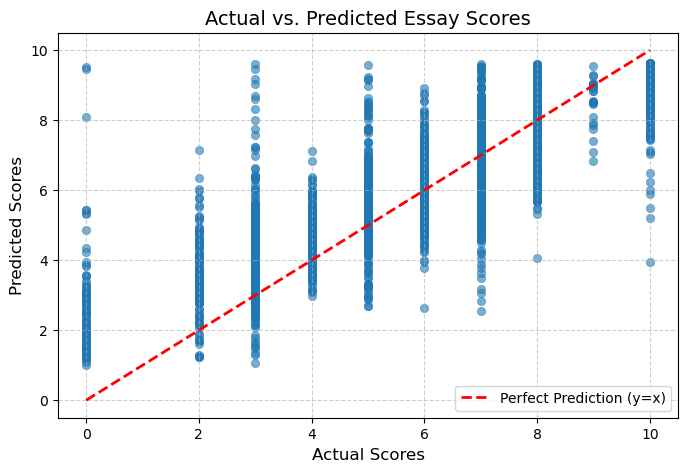

In [ ]:

data = pd.read_csv("bert_predictions.csv")

# Assuming the CSV file has columns 'actual_score' and 'predicted_score'
true_labels = data['final_score']
final_predictions = data['predicted_score']

# Create figure
plt.figure(figsize=(8, 5))

# Add scatter plot with improved visualization
sns.scatterplot(x=true_labels, y=final_predictions, alpha=0.6, edgecolor=None)

# Add identity line (y = x) for reference
plt.plot([min(true_labels), max(true_labels)], [min(true_labels), max(true_labels)], 
         color='red', linestyle='dashed', linewidth=2, label="Perfect Prediction (y=x)")

# Improve labels and title
plt.xlabel("Actual Scores", fontsize=12)
plt.ylabel("Predicted Scores", fontsize=12)
plt.title("Actual vs. Predicted Essay Scores", fontsize=14)

# Add grid for better readability
plt.grid(True, linestyle='--', alpha=0.6)

# Show plot
plt.legend()
plt.show()


In [39]:
essays = {
    "Repeated Sentences": """Technology is important. Technology is important. Technology is important.
                             Technology is important. Technology is important. Technology is important.
                             Technology is important. Technology is important. Technology is important.
                             Technology is important.""",

 "reworded_sentences" : """Technology is a big part of our daily lives, helping us do things faster and stay connected.  
Technology fits easily into our daily routines, making work easier and helping us talk to others.  
We use technology every day to make things simpler and stay in touch with people.  
Technology helps us work better and talk to friends and family more easily.  
Using technology makes our daily tasks easier and helps us stay connected.  
New technology makes life simpler and helps people talk to each other easily.  
Technology is very important in today’s world because it helps us do things quickly and stay in touch.  
Having technology in our daily life makes things more convenient and helps us talk instantly.  
New gadgets and tools make daily work easier and help people stay connected.  
Technology helps us in many ways, making tasks simple and keeping us close to others. """,



    "diverse_content"  : """Technology has changed the way people communicate,
      making instant global connections easy and accessible. Digital platforms and social media help individuals
        and businesses collaborate across borders in real time. Artificial intelligence is transforming industries
          by automating complex tasks with high accuracy and efficiency. AI improves decision-making in areas like
            healthcare and finance, reducing errors and increasing productivity. Automation in manufacturing has boosted
              efficiency, cutting costs and reducing the need for manual labor. Online education removes geographical
                barriers, allowing students worldwide to access knowledge instantly. The internet has made information
                  widely available, giving people access to learning resources anytime. Medical technology, including
                    AI diagnostics and robotic surgeries, has greatly improved patient care. E-commerce and digital payments 
                    have changed how people shop, making transactions faster and more convenient. As AI and automation continue 
                    to grow, ethical concerns must be addressed to ensure responsible innovation."""
}


In [40]:
def predict_score(essay):
    inputs = tokenizer(essay, return_tensors="pt", truncation=True, padding="max_length", max_length=512)
    inputs = {k: v.to(device) for k, v in inputs.items()}
    with torch.no_grad():
        output = model(**inputs)
    return output.logits.item()


In [ ]:
# Get scores for each essay type
scores = {key: predict_score(value) for key, value in essays.items()}

# Display results
print("\n===== Custom Essay Evaluation =====")
for category, score in scores.items():
    print(f"{category}: {score:.4f}")


===== Custom Essay Evaluation =====
Repeated Sentences: 2.2807
Reworded Sentences: 4.1352
Diverse Content: 8.6353
